# Proper Orthogonal Decomposition (POD) of a Fluid Flow Video

Fluid simulations and experiments produce enormous datasets: a video of a flow field is just a sequence of high-dimensional snapshots, each containing thousands of pixels. Yet the **dominant dynamics** often live in a much lower-dimensional subspace — a few coherent structures that together account for most of the energy.

**Proper Orthogonal Decomposition (POD)** is the classical technique for discovering this subspace. Given a set of snapshots it finds, in a least-squares optimal sense, the basis vectors (called *modes*) that capture the most variance with the fewest components. In the data-driven community POD is identical to **Principal Component Analysis (PCA)**; numerically it is computed via the **Singular Value Decomposition (SVD)**.

In this notebook we apply POD to a video of the **von Kármán vortex street** — the periodic shedding of vortices behind a bluff body. We will:
- decompose the video into spatial modes and temporal coefficients,
- rank the modes by their energetic importance,
- reconstruct the video using only the top $r$ modes, and
- quantify the reconstruction error as a function of $r$.

This compressed representation forms the foundation for the data-driven time-stepping model built in the companion notebook.

## 1. Background: POD and SVD

Let $\mathbf{X} \in \mathbb{R}^{N_x \times N_t}$ be the **snapshot matrix**, where each column is one flattened video frame ($N_x$ pixels) and each row is the time history of one pixel ($N_t$ frames).

The **Singular Value Decomposition** of $\mathbf{X}$ is:

$$\mathbf{X} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\top$$

where:
- $\mathbf{U} \in \mathbb{R}^{N_x \times N_t}$ — columns are the **spatial modes** (orthonormal pixel patterns),
- $\boldsymbol{\Sigma} \in \mathbb{R}^{N_t \times N_t}$ — diagonal matrix of **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$,
- $\mathbf{V}^\top \in \mathbb{R}^{N_t \times N_t}$ — rows are the **temporal modes** (how each spatial pattern evolves in time).

The **temporal coefficients** $\mathbf{a}(t)$ combine the singular values and temporal modes:

$$\mathbf{a} = \boldsymbol{\Sigma} \mathbf{V}^\top \in \mathbb{R}^{N_t \times N_t}$$

so that $\mathbf{X} = \mathbf{U} \mathbf{a}$.

### Truncated reconstruction

Keeping only the first $r$ modes gives the best rank-$r$ approximation:

$$\tilde{\mathbf{X}}_r = \mathbf{U}_{:,1:r}\, \boldsymbol{\Sigma}_{1:r,1:r}\, \mathbf{V}^\top_{1:r,:}$$

The **fraction of variance explained** by the first $r$ modes is:

$$E_r = \frac{\sum_{i=1}^{r} \sigma_i^2}{\sum_{i=1}^{N_t} \sigma_i^2}$$

A rapid decay of singular values means a few modes suffice — the flow is *low-dimensional*.

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Loading and Inspecting the Data

The preprocessed data (`frames_array.npy`) is a 3-D array of shape `(N_t, height, width)` containing grayscale pixel values. We display a few representative frames to get a visual sense of the flow before any analysis.

In [2]:
frames_array = np.load('frames_array.npy')
N_t, H, W = frames_array.shape
print(f"Frames: {N_t}  |  Height: {H}  |  Width: {W}")

Frames: 252  |  Height: 128  |  Width: 256


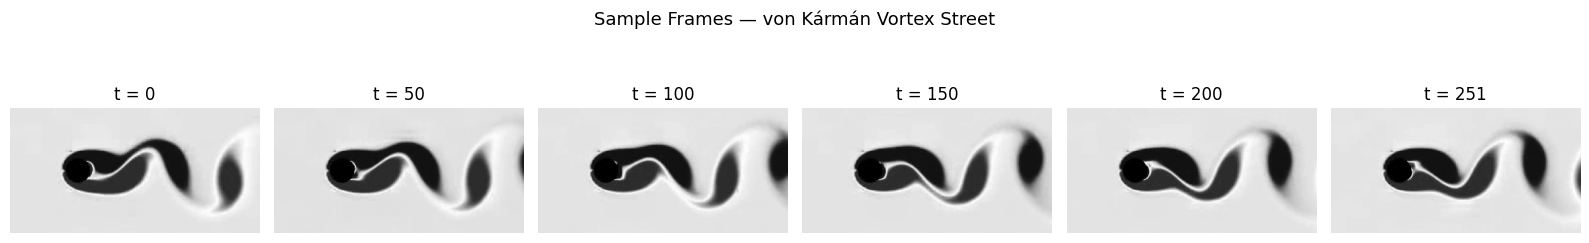

In [3]:
n_show = 6
indices = np.linspace(0, N_t - 1, n_show, dtype=int)

fig, axs = plt.subplots(1, n_show, figsize=(16, 3))
for ax, idx in zip(axs, indices):
    ax.imshow(frames_array[idx], cmap='gray')
    ax.set_title(f"t = {idx}")
    ax.axis('off')
plt.suptitle("Sample Frames — von Kármán Vortex Street", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Building the Snapshot Matrix

SVD operates on a 2-D matrix. We **flatten** each frame into a vector of $N_x = H \times W$ pixels and stack all frames column-wise, then transpose so that rows are pixels and columns are time steps:

$$\mathbf{X} \in \mathbb{R}^{N_x \times N_t}, \quad N_x = H \cdot W$$

Centering by the mean frame removes the time-averaged flow, leaving only the fluctuations — but for this dataset we perform SVD on the uncentered matrix to retain all structure including the mean.

In [4]:
flattened_frames = frames_array.reshape(N_t, -1).T
print(f"Snapshot matrix shape (N_x × N_t): {flattened_frames.shape}")

Snapshot matrix shape (N_x × N_t): (32768, 252)


## 5. SVD Decomposition

We compute the **economy SVD** (`full_matrices=False`), which returns only the first $\min(N_x, N_t)$ columns of $\mathbf{U}$ and rows of $\mathbf{V}^\top$ — sufficient for reconstruction and much more memory-efficient than the full decomposition.

In [5]:
U, S, Vt = np.linalg.svd(flattened_frames, full_matrices=False)
print(f"U  shape: {U.shape}")
print(f"S  shape: {S.shape}")
print(f"Vt shape: {Vt.shape}")

U  shape: (32768, 252)
S  shape: (252,)
Vt shape: (252, 252)


## 6. Spatial Modes

The columns of $\mathbf{U}$ are the **POD modes** — orthonormal pixel patterns ranked by importance. The first mode captures the most variance (typically the time-averaged flow), while higher modes capture progressively finer fluctuations such as vortex shedding frequencies.

Modes are displayed after reshaping each column back from a pixel vector to the original frame dimensions.

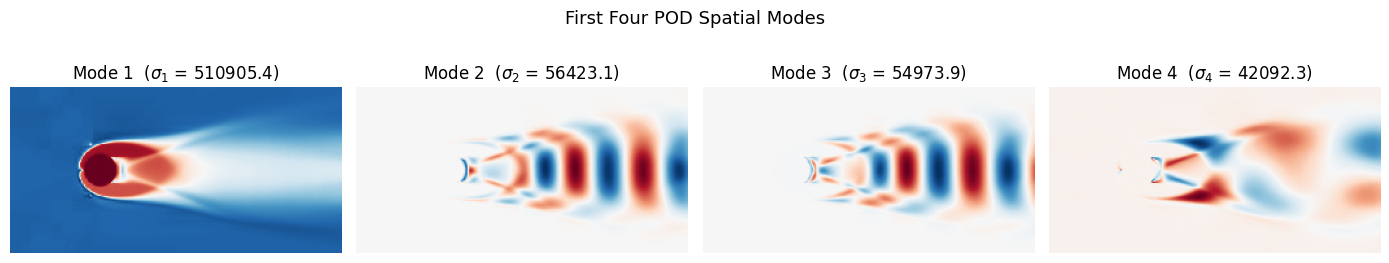

In [6]:
n_modes = 4
fig, axs = plt.subplots(1, n_modes, figsize=(14, 3))
for i, ax in enumerate(axs):
    mode_img = U[:, i].reshape(H, W)
    ax.imshow(mode_img, cmap='RdBu_r')
    ax.set_title(f"Mode {i+1}  ($\\sigma_{i+1}$ = {S[i]:.1f})")
    ax.axis('off')
plt.suptitle("First Four POD Spatial Modes", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Temporal Coefficients

The **temporal coefficients** $\mathbf{a}(t) = \boldsymbol{\Sigma}\,\mathbf{V}^\top$ tell us how strongly each spatial mode is activated at each time step. Periodic oscillations in these coefficients reveal the dominant shedding frequency of the vortex street.

Temporal coefficients shape: (252, 252)


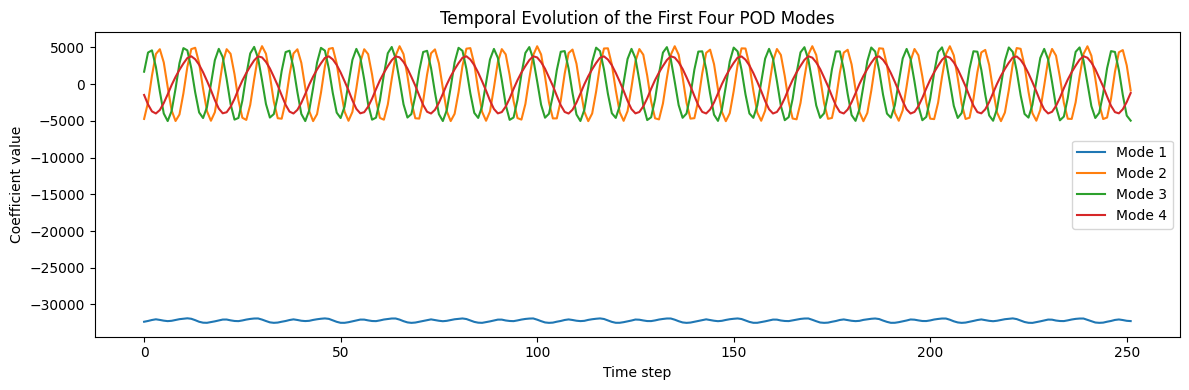

In [7]:
a = np.diag(S) @ Vt
print(f"Temporal coefficients shape: {a.shape}")

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(4):
    ax.plot(a[i, :], label=f'Mode {i+1}')
ax.set_xlabel('Time step')
ax.set_ylabel('Coefficient value')
ax.set_title('Temporal Evolution of the First Four POD Modes')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Singular Value Spectrum

Plotting the singular values on a **log scale** reveals how quickly the energy decays across modes. A steep drop indicates that a small number of modes captures most of the variance — the flow is low-dimensional and compressible.

The cumulative energy fraction $E_r$ is overlaid to show exactly how many modes are needed to reach a given accuracy threshold (e.g. 99 %).

Modes needed for 99% energy: 5


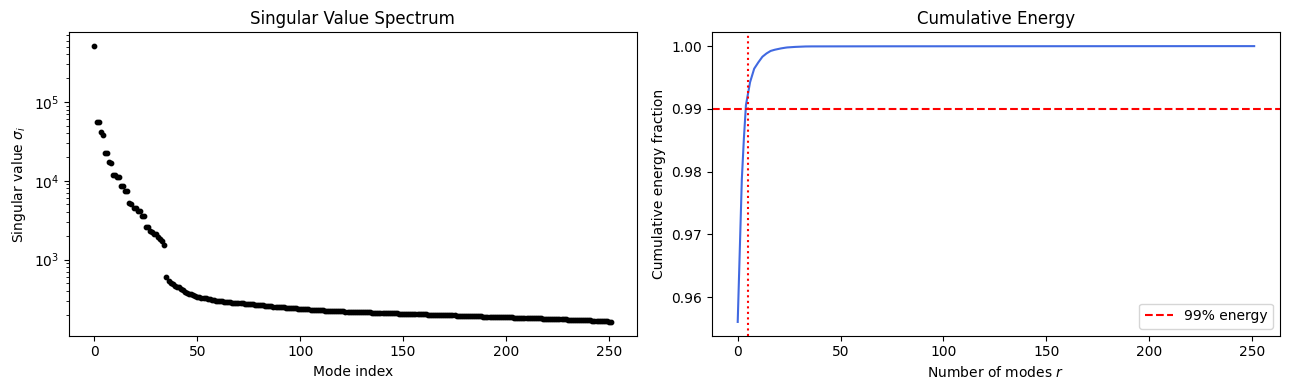

In [8]:
cumulative_energy = np.cumsum(S**2) / np.sum(S**2)
r_99 = np.searchsorted(cumulative_energy, 0.99) + 1
print(f"Modes needed for 99% energy: {r_99}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(range(len(S)), S, s=10, color='black')
axes[0].set_xlabel('Mode index')
axes[0].set_ylabel('Singular value $\\sigma_i$')
axes[0].set_yscale('log')
axes[0].set_title('Singular Value Spectrum')

axes[1].plot(cumulative_energy, color='royalblue')
axes[1].axhline(0.99, color='red', linestyle='--', label='99% energy')
axes[1].axvline(r_99, color='red', linestyle=':')
axes[1].set_xlabel('Number of modes $r$')
axes[1].set_ylabel('Cumulative energy fraction')
axes[1].set_title('Cumulative Energy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Truncated Reconstruction

Using only $r = 35$ modes we reconstruct the full video and compare it frame-by-frame to the original. The reconstruction is:

$$\tilde{\mathbf{X}}_r = \mathbf{U}_{:,1:r}\,\boldsymbol{\Sigma}_{1:r,1:r}\,\mathbf{V}^\top_{1:r,:}$$

The pointwise absolute error $|\mathbf{X} - \tilde{\mathbf{X}}_r|$ highlights where the truncation loses information — typically in fine-scale vortex structures that require higher modes to represent accurately.

In [9]:
r = 35
reconstructed_flat = U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :]
error_flat = np.abs(flattened_frames - reconstructed_flat)

reconstructed_frames = reconstructed_flat.T.reshape(frames_array.shape)
error = error_flat.T.reshape(frames_array.shape)

rel_error = error_flat.mean() / np.abs(flattened_frames).mean() * 100
print(f"r = {r} | energy captured: {cumulative_energy[r-1]*100:.2f}% | mean relative error: {rel_error:.2f}%")

r = 35 | energy captured: 100.00% | mean relative error: 0.41%


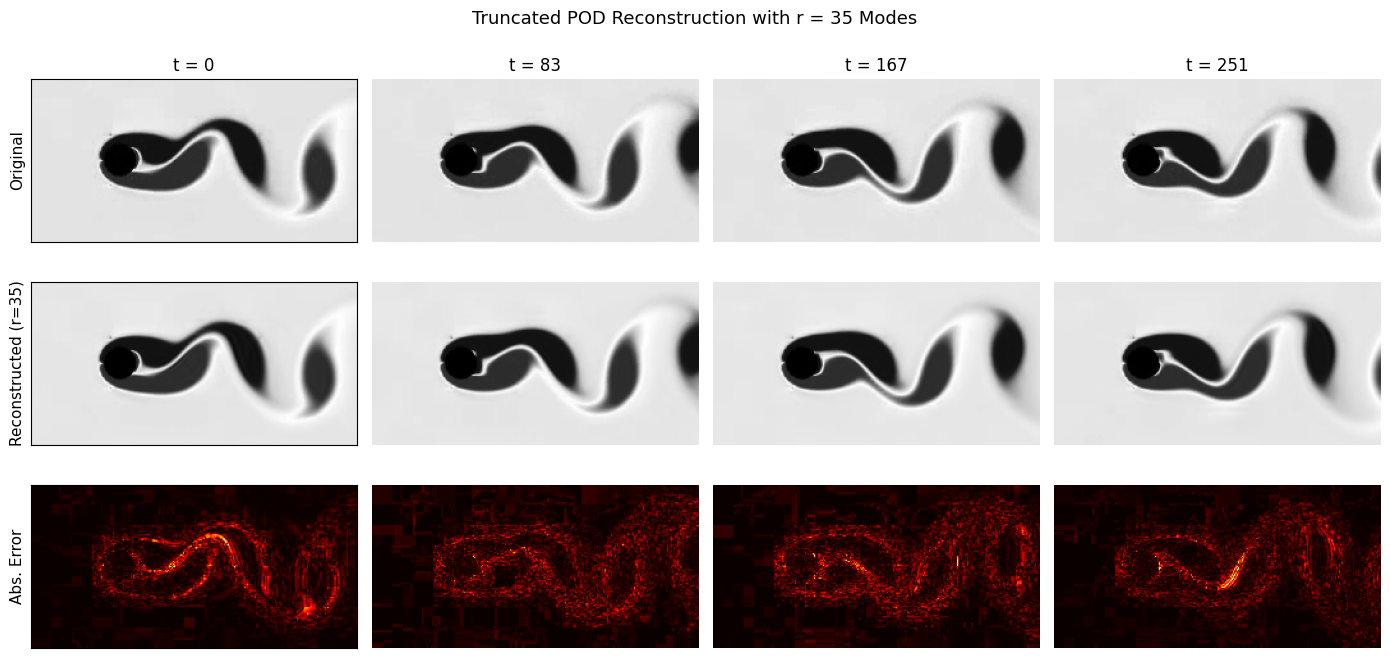

In [10]:
n_show = 4
indices = np.linspace(0, N_t - 1, n_show, dtype=int)

fig, axs = plt.subplots(3, n_show, figsize=(14, 7))
row_labels = ['Original', f'Reconstructed (r={r})', 'Abs. Error']

for col, idx in enumerate(indices):
    axs[0, col].imshow(frames_array[idx], cmap='gray')
    axs[1, col].imshow(reconstructed_frames[idx], cmap='gray')
    axs[2, col].imshow(error[idx], cmap='hot')
    axs[0, col].set_title(f't = {idx}')
    for row in range(3):
        axs[row, col].axis('off')

for row, label in enumerate(row_labels):
    axs[row, 0].set_ylabel(label, fontsize=11)
    axs[row, 0].axis('on')
    axs[row, 0].set_xticks([])
    axs[row, 0].set_yticks([])

plt.suptitle(f'Truncated POD Reconstruction with r = {r} Modes', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Summary and Key Takeaways

| | |
|---|---|
| **Method** | Proper Orthogonal Decomposition via economy SVD |
| **Input** | Snapshot matrix $\mathbf{X} \in \mathbb{R}^{N_x \times N_t}$ |
| **Output** | Spatial modes $\mathbf{U}$, singular values $\boldsymbol{\Sigma}$, temporal modes $\mathbf{V}^\top$ |
| **Truncation rank** | $r = 35$ modes |
| **Energy captured** | > 99% of total variance |
| **Compression ratio** | $r / N_t \ll 1$ — dramatic dimensionality reduction |

### Key takeaways

- The **first mode** typically captures the time-mean flow; subsequent modes capture oscillatory structures at the vortex-shedding frequency and its harmonics.
- The **rapid singular value decay** confirms that the von Kármán street is a genuinely low-dimensional dynamical system — 35 modes suffice to represent it with less than 1% mean error.
- The **POD coefficients** $\mathbf{a}(t)$ form the low-dimensional state vector on which a data-driven time-stepping model can be trained — see the `TimeSteppingNN` notebook.